<a href="https://colab.research.google.com/github/A-Ohanusi/Credit-Risk-Model-for-Lending-Against-Bitcoin-Collateral/blob/main/Bitcoin_Parameter_estimation_Jump_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

btc = pd.read_csv("btc_raw.csv")


btc = btc.iloc[2:].copy()


btc = btc.rename(columns={"Price": "Date"})

btc["Date"] = pd.to_datetime(
    btc["Date"],
    dayfirst=True,
    errors="coerce"
)

numeric_columns = ["Close", "High", "Low", "Open", "Volume"]

for column in numeric_columns:
    btc[column] = pd.to_numeric(
        btc[column],
        errors="coerce"
    )

btc = (
    btc.dropna(subset=["Date", "Close"])
    .sort_values("Date")
    .reset_index(drop=True)
)

btc["log_return"] = np.log(
    btc["Close"] / btc["Close"].shift(1)
)

btc = btc.dropna(subset=["log_return"])

print(btc.head())
print(btc["Date"].min(), btc["Date"].max())

        Date        Close         High          Low         Open  \
1 2018-01-02  14982.09961  15444.59961  13163.59961  13625.00000   
2 2018-01-03  15201.00000  15572.79980  14844.50000  14978.20020   
3 2018-01-04  15599.20020  15739.70020  14522.20020  15270.70020   
4 2018-01-05  17429.50000  17705.19922  15202.79980  15477.20020   
5 2018-01-06  17527.00000  17712.40039  16764.59961  17462.09961   

         Volume  log_return  
1  1.684660e+10    0.092589  
2  1.687190e+10    0.014505  
3  2.178320e+10    0.025858  
4  2.384090e+10    0.110945  
5  1.831460e+10    0.005578  
2018-01-02 00:00:00 2026-07-02 00:00:00


In [4]:
returns = btc["log_return"].copy()

mean_return = returns.mean()
return_std = returns.std()

threshold = 3 * return_std

jump_mask = np.abs(
    returns - mean_return
) > threshold

jump_returns = returns[jump_mask]
diffusion_returns = returns[~jump_mask]

print("Number of jumps:", len(jump_returns))
print("Total observations:", len(returns))

Number of jumps: 57
Total observations: 3104


In [5]:
trading_days = 365
dt = 1 / trading_days

# Diffusion parameters
mu_daily = diffusion_returns.mean()
sigma_daily = diffusion_returns.std()

mu_annual = mu_daily * trading_days
sigma_annual = sigma_daily * np.sqrt(trading_days)

# Jump parameters
years = len(returns) / trading_days

lambda_annual = len(jump_returns) / years
jump_mean = jump_returns.mean()
jump_std = jump_returns.std()

print("Annual drift:", mu_annual)
print("Annual diffusion volatility:", sigma_annual)
print("Jump intensity:", lambda_annual)
print("Mean jump size:", jump_mean)
print("Jump-size volatility:", jump_std)

Annual drift: 0.3652811096366128
Annual diffusion volatility: 0.5422935118740928
Jump intensity: 6.702641752577319
Mean jump size: -0.027402239469623824
Jump-size volatility: 0.13690701827327986


In [6]:
negative_jumps = jump_returns[jump_returns < 0]
positive_jumps = jump_returns[jump_returns > 0]

negative_jump_intensity = (
    len(negative_jumps) / years
)

positive_jump_intensity = (
    len(positive_jumps) / years
)

print("Negative jump intensity:", negative_jump_intensity)
print("Negative jump mean:", negative_jumps.mean())
print("Negative jump volatility:", negative_jumps.std())

print("Positive jump intensity:", positive_jump_intensity)
print("Positive jump mean:", positive_jumps.mean())
print("Positive jump volatility:", positive_jumps.std())

Negative jump intensity: 3.880476804123711
Negative jump mean: -0.13512456090216995
Negative jump volatility: 0.06388125887449249
Positive jump intensity: 2.822164948453608
Positive jump mean: 0.12071595250012712
Positive jump volatility: 0.020409356699219096


In [7]:
def simulate_merton_jump_diffusion(
    initial_price,
    mu,
    sigma,
    jump_intensity,
    jump_mean,
    jump_std,
    years=1,
    steps=365,
    simulations=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    dt = years / steps

    paths = np.zeros((steps + 1, simulations))
    paths[0] = initial_price

    jump_compensator = (
        np.exp(jump_mean + 0.5 * jump_std**2) - 1
    )

    for t in range(1, steps + 1):
        z = rng.normal(size=simulations)

        jump_counts = rng.poisson(
            jump_intensity * dt,
            size=simulations
        )

        jump_sizes = np.zeros(simulations)

        active = jump_counts > 0

        jump_sizes[active] = rng.normal(
            loc=jump_counts[active] * jump_mean,
            scale=np.sqrt(jump_counts[active]) * jump_std
        )

        diffusion = (
            mu
            - 0.5 * sigma**2
            - jump_intensity * jump_compensator
        ) * dt + sigma * np.sqrt(dt) * z

        paths[t] = paths[t - 1] * np.exp(
            diffusion + jump_sizes
        )

    return paths

In [8]:
paths = simulate_merton_jump_diffusion(
    initial_price=btc["Close"].iloc[-1],
    mu=mu_annual,
    sigma=sigma_annual,
    jump_intensity=lambda_annual,
    jump_mean=jump_mean,
    jump_std=jump_std
)

terminal_prices = paths[-1]

print("Mean terminal price:", terminal_prices.mean())
print("5% percentile:", np.percentile(terminal_prices, 5))
print("1% percentile:", np.percentile(terminal_prices, 1))

Mean terminal price: 87734.1486418554
5% percentile: 23844.79279758871
1% percentile: 15356.563953963723


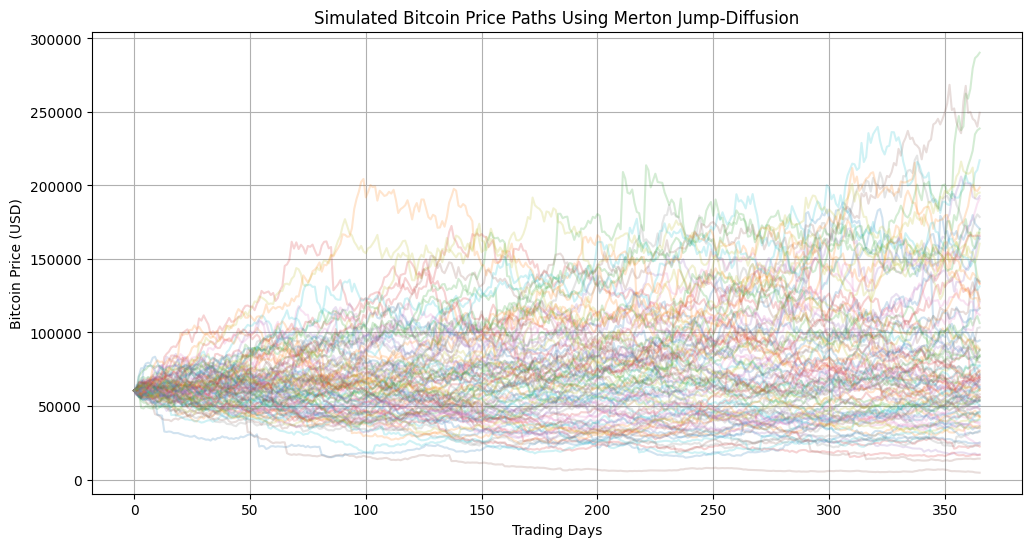

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot the first 100 simulated paths
for i in range(100):
    plt.plot(paths[:, i], alpha=0.2)

plt.title("Simulated Bitcoin Price Paths Using Merton Jump-Diffusion")
plt.xlabel("Trading Days")
plt.ylabel("Bitcoin Price (USD)")
plt.grid(True)

plt.show()